In [9]:
import os
import json

# Kaggle credentials
kaggle_config = {
    "username": "rijamalik971",
    "key": "KGAT_4cfa192a856953a0d5a273414fd02bbd"
}

# Config file
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle configured!")

# Dataset download
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
print(" Downloaded!")

Kaggle configured!
Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:02<00:00, 199MB/s]

 Downloaded!


In [10]:
# Unzip file
!unzip -q ravdess-emotional-speech-audio.zip -d /content/ravdess
print("Unzipped!")

# File Check
import os
actors = os.listdir('/content/ravdess')
print(f"Folders: {len(actors)}")
print(actors[:5])

Unzipped!
Folders: 25
['Actor_23', 'Actor_03', 'Actor_11', 'Actor_21', 'Actor_08']


In [11]:
# Audio files and labels loading
import librosa
import numpy as np
import os

data_path = '/content/ravdess'

# RAVDESS emotion labels
emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

audio_files = []
labels = []

for actor in sorted(os.listdir(data_path)):
    actor_path = os.path.join(data_path, actor)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith('.wav'):
                emotion_code = file.split('-')[2]
                if emotion_code in emotion_map:
                    audio_files.append(os.path.join(actor_path, file))
                    labels.append(emotion_map[emotion_code])

print(f"Total audio files: {len(audio_files)}")
print(f"Emotions found: {set(labels)}")

import pandas as pd
df = pd.DataFrame({'file': audio_files, 'emotion': labels})
print(f"\nEmotion distribution:")
print(df['emotion'].value_counts())

Total audio files: 1440
Emotions found: {'sad', 'neutral', 'fearful', 'angry', 'disgust', 'calm', 'surprised', 'happy'}

Emotion distribution:
emotion
surprised    192
fearful      192
sad          192
disgust      192
happy        192
calm         192
angry        192
neutral       96
Name: count, dtype: int64


In [12]:
# MFCC Features extraction
print("Extracting MFCC features..)")

def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, duration=3, offset=0.5)

        # MFCCs
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfcc_mean = np.mean(mfcc.T, axis=0)

        # Chroma
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)

        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=audio, sr=sr)
        mel_mean = np.mean(mel.T, axis=0)

        # Combine features
        features = np.concatenate([mfcc_mean, chroma_mean, mel_mean])
        return features
    except:
        return None

# Extract Features from all files
X = []
y = []

for i, (file, emotion) in enumerate(zip(audio_files, labels)):
    features = extract_features(file)
    if features is not None:
        X.append(features)
        y.append(emotion)

    if (i+1) % 100 == 0:
        print(f"Processed {i+1}/{len(audio_files)} files...")

X = np.array(X)
y = np.array(y)

print(f"\nFeature extraction complete!")
print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Extracting MFCC features..)
Processed 100/1440 files...
Processed 200/1440 files...
Processed 300/1440 files...
Processed 400/1440 files...
Processed 500/1440 files...
Processed 600/1440 files...
Processed 700/1440 files...
Processed 800/1440 files...
Processed 900/1440 files...
Processed 1000/1440 files...
Processed 1100/1440 files...
Processed 1200/1440 files...
Processed 1300/1440 files...
Processed 1400/1440 files...

Feature extraction complete!
Features shape: (1440, 180)
Labels shape: (1440,)


In [13]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train or Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Preprocessing done!")
print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {le.classes_}")

Preprocessing done!
Train samples: 1152
Test samples: 288
Features: 180
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [14]:
# Deep Learning Model
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(180,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(8, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("Model ready!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        92,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,256 (1.03 MB)

 Trainable params: 267,464 (1.02 MB)

 Non-trainable params: 1,792 (7.00 KB)

Model ready!


In [15]:
# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_emotion_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

# Training
print("Training starts...")
print("(It will take 10-15 min.")
print(" "*50)

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print("  "*50)
print("Training complete!")

Training starts...
(It will take 10-15 min.
                                                  
Epoch 1/100
28/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1448 - loss: 2.7242
Epoch 1: val_accuracy improved from None to 0.25000, saving model to best_emotion_model.keras

Epoch 1: finished saving model to best_emotion_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.1902 - loss: 2.4313 - val_accuracy: 0.2500 - val_loss: 1.9547 - learning_rate: 0.0010
Epoch 2/100
30/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2773 - loss: 1.9647
Epoch 2: val_accuracy improved from 0.25000 to 0.32759, saving model to best_emotion_model.keras

Epoch 2: finished saving model to best_emotion_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3098 - loss: 1.9089 - val_accuracy: 0.3276 - val_loss: 1.8805 - learning_rate: 0.0010
Epoch 3/100
29/33 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3584 - loss: 1.7735
Epoch 3: val_accuracy improved from 0.32759 to 0.37069, s

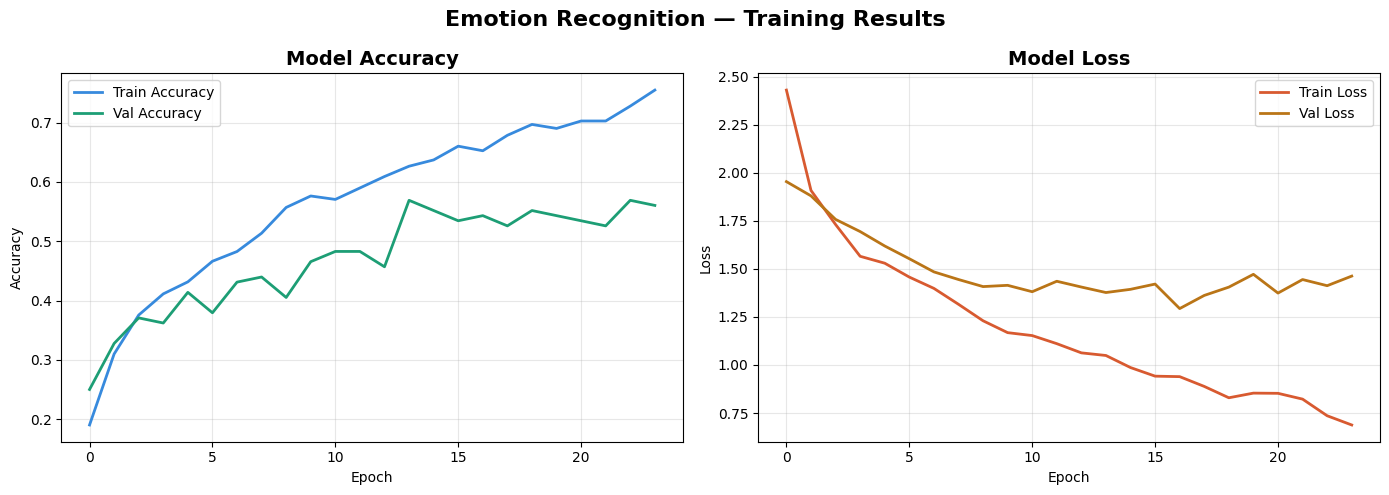

Graphs saved!


In [16]:
# Training graphs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],
             color='#378ADD', linewidth=2, label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'],
             color='#1D9E75', linewidth=2, label='Val Accuracy')
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],
             color='#D85A30', linewidth=2, label='Train Loss')
axes[1].plot(history.history['val_loss'],
             color='#BA7517', linewidth=2, label='Val Loss')
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Emotion Recognition — Training Results',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphs saved!")

Test Accuracy: 48.61%


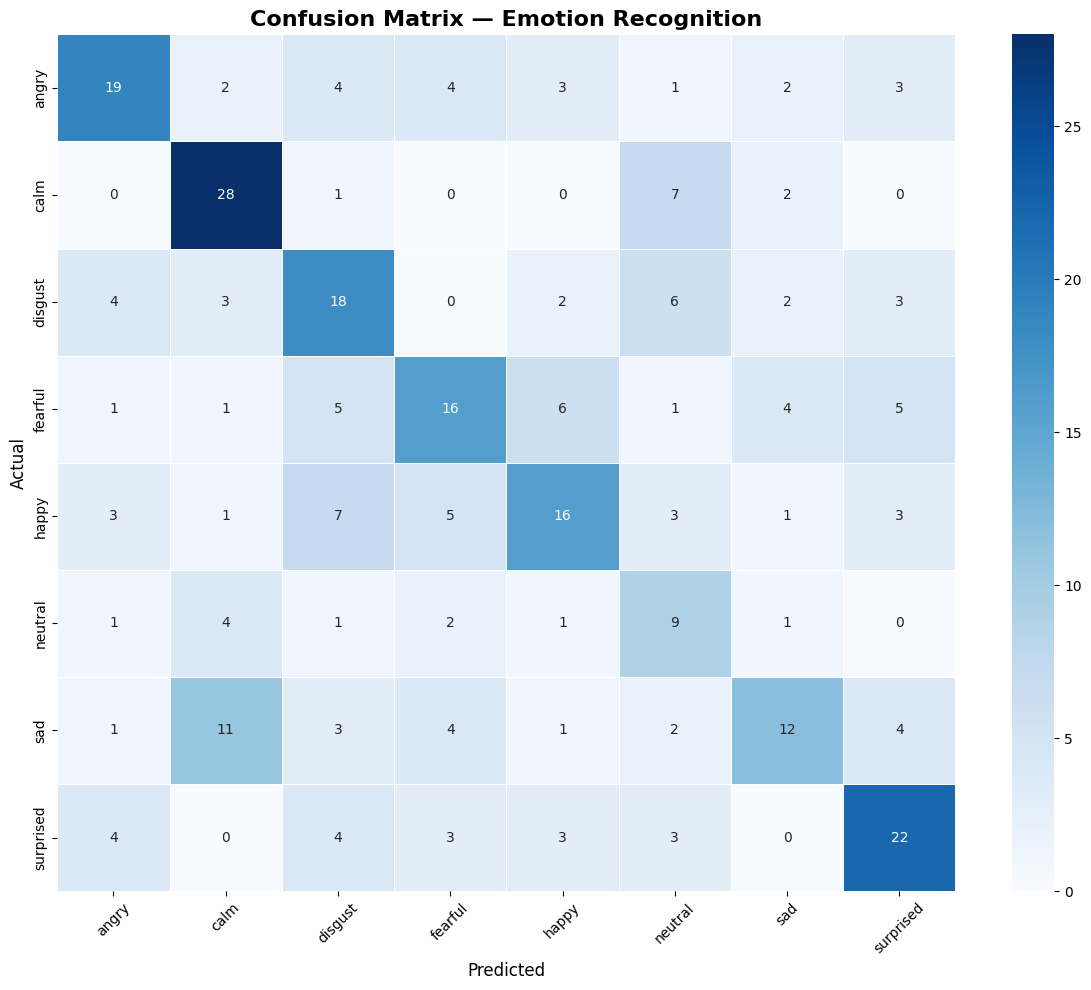


Classification Report:
                                                            
              precision    recall  f1-score   support

       angry       0.58      0.50      0.54        38
        calm       0.56      0.74      0.64        38
     disgust       0.42      0.47      0.44        38
     fearful       0.47      0.41      0.44        39
       happy       0.50      0.41      0.45        39
     neutral       0.28      0.47      0.35        19
         sad       0.50      0.32      0.39        38
   surprised       0.55      0.56      0.56        39

    accuracy                           0.49       288
   macro avg       0.48      0.49      0.48       288
weighted avg       0.50      0.49      0.48       288



In [17]:
# Model evaluation
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.5)
plt.title('Confusion Matrix — Emotion Recognition',
          fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\nClassification Report:")
print(" "*60)
print(classification_report(y_true_classes, y_pred_classes,
                            target_names=le.classes_))

In [18]:
# Model saving
model.save('emotion_recognition_model.keras')
print("Model saved!")

Model saved!


In [21]:
import librosa
import numpy as np

def predict_emotion(file_path):
    # Features extract
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)

    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)

    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_mean = np.mean(mel.T, axis=0)

    features = np.concatenate([mfcc_mean, chroma_mean, mel_mean])
    features_scaled = scaler.transform([features])

    # Predict karo
    prediction = model.predict(features_scaled, verbose=0)
    emotion = le.classes_[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    print(f" Predicted Emotion: {emotion.upper()}")
    print(f" Confidence: {confidence:.2f}%")

    # Top 3
    top3 = np.argsort(prediction[0])[::-1][:3]
    print("\nTop 3 predictions:")
    for i in top3:
        print(f"  {le.classes_[i]}: {prediction[0][i]*100:.2f}%")

# Apni audio file upload karo
from google.colab import files
print("Audio file upload karo (.wav format)")
uploaded = files.upload()

# Test karo
for filename in uploaded.keys():
    predict_emotion(filename)

Audio file upload karo (.wav format)


Saving rija.ogg to rija (1).ogg
 Predicted Emotion: FEARFUL
 Confidence: 100.00%

Top 3 predictions:
  fearful: 100.00%
  sad: 0.00%
  calm: 0.00%
